In [1]:
#importing and setup
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
#loading the dataset

products  = pd.read_csv("../data/raw/products.csv")
holidays  = pd.read_csv("../data/raw/holidays.csv")
sales     = pd.read_csv("../data/raw/sales.csv", parse_dates=["transaction_ts"])
inventory = pd.read_csv("../data/raw/inventory.csv", parse_dates=["baked_at"])
staff     = pd.read_csv("../data/raw/staff.csv", parse_dates=["shift_date"])

print("✅ All datasets loaded!")
print(f"Sales shape:     {sales.shape}")
print(f"Inventory shape: {inventory.shape}")
print(f"Staff shape:     {staff.shape}")

✅ All datasets loaded!
Sales shape:     (45664, 16)
Inventory shape: (6564, 10)
Staff shape:     (3282, 9)


In [3]:
#sales data

print(sales.head(10))
print("\nColumn types:")
print(sales.dtypes)
print("\nBasic stats:")
print(sales.describe())

                         transaction_id product_id      product_name  \
0  27ae35df-cf85-448c-9b5c-75dc715acc72       P011  Blueberry Muffin   
1  dabe3407-53f1-47b1-81e9-e9f6ee1eb8da       P011  Blueberry Muffin   
2  bdcf00a3-2041-4a67-b0dc-106baab07419       P008     Cheese Danish   
3  bb72f933-0d2d-4685-b072-ca79524e591c       P010       Custom Cake   
4  6e3fcf23-8111-4e47-9a8e-d4f4b691dee6       P001  Butter Croissant   
5  8d7e6d25-e44e-44fd-8cd2-153a99c77770       P009          Baguette   
6  fb74f792-c05c-41ad-a563-b41f0e684022       P003     Almond Danish   
7  0cfc3895-cbcc-4319-866a-f3a94afe9eb2       P003     Almond Danish   
8  175a5c54-1241-47e9-8b61-dd2603c5ce76       P002    Sourdough Loaf   
9  63b2f101-d4cd-41de-bad1-fe28a7cb3b69       P007       Macaron Box   

     category  quantity  unit_price  unit_cost  revenue  cogs  gross_margin  \
0      Muffin         1         3.0        0.7      3.0   0.7           2.3   
1      Muffin         3         3.0        0.7   

#####  Null Values check

In [4]:
#null values

datasets = {"Sales": sales, "Inventory": inventory, "Staff": staff, "Products": products}

for name, df in datasets.items():
    nulls = df.isnull().sum().sum()
    print(f"{name}: {nulls} null values — {'✅ Clean' if nulls == 0 else '⚠️ Needs cleaning'}")


Sales: 0 null values — ✅ Clean
Inventory: 0 null values — ✅ Clean
Staff: 0 null values — ✅ Clean
Products: 0 null values — ✅ Clean


##### Total revenue overview

In [5]:

total_revenue = sales["revenue"].sum()
total_margin  = sales["gross_margin"].sum()
total_orders  = len(sales)
avg_order     = sales["revenue"].mean()

print(f"💰 Total Revenue:       ${total_revenue:,.2f}")
print(f"📈 Total Gross Margin:  ${total_margin:,.2f}")
print(f"🧾 Total Transactions:  {total_orders:,}")
print(f"🛒 Avg Order Value:     ${avg_order:.2f}")
print(f"📊 Margin %:            {(total_margin/total_revenue*100):.1f}%")

💰 Total Revenue:       $1,020,559.00
📈 Total Gross Margin:  $750,690.00
🧾 Total Transactions:  45,664
🛒 Avg Order Value:     $22.35
📊 Margin %:            73.6%


##### Daily revenue over time:

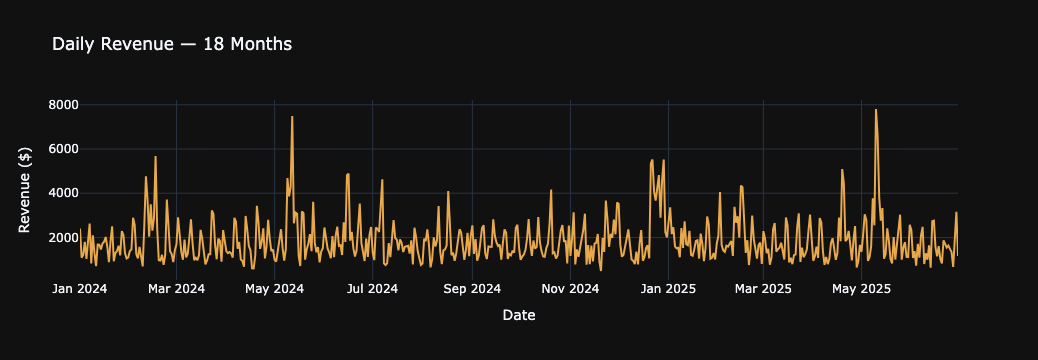

In [6]:
daily_revenue = sales.groupby(sales["transaction_ts"].dt.date)["revenue"].sum().reset_index()
daily_revenue.columns = ["date", "revenue"]

fig = px.line(
    daily_revenue, x="date", y="revenue",
    title="Daily Revenue — 18 Months",
    template="plotly_dark",
    color_discrete_sequence=["#E8A84C"]
)
fig.update_layout(xaxis_title="Date", yaxis_title="Revenue ($)")
fig.show()

#### Revenue by day of week:

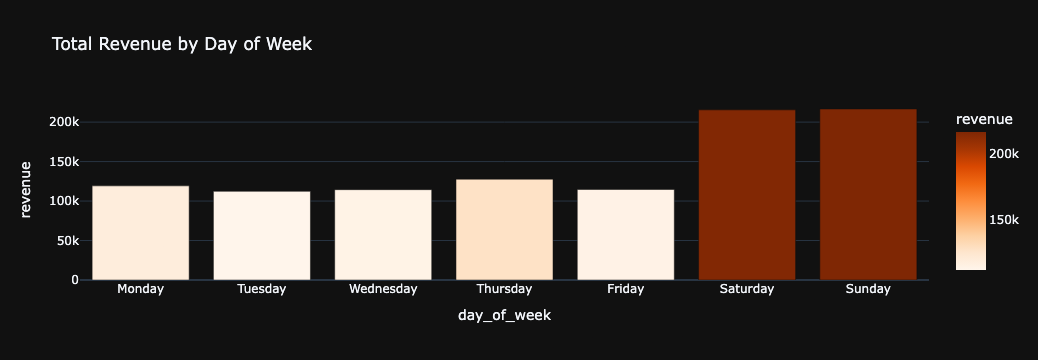

In [7]:
dow_revenue = sales.groupby("day_of_week")["revenue"].sum().reset_index()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_revenue["day_of_week"] = pd.Categorical(dow_revenue["day_of_week"], categories=order, ordered=True)
dow_revenue = dow_revenue.sort_values("day_of_week")

fig = px.bar(
    dow_revenue, x="day_of_week", y="revenue",
    title="Total Revenue by Day of Week",
    template="plotly_dark",
    color="revenue",
    color_continuous_scale="Oranges"
)
fig.show()

##### Top products by revenue:

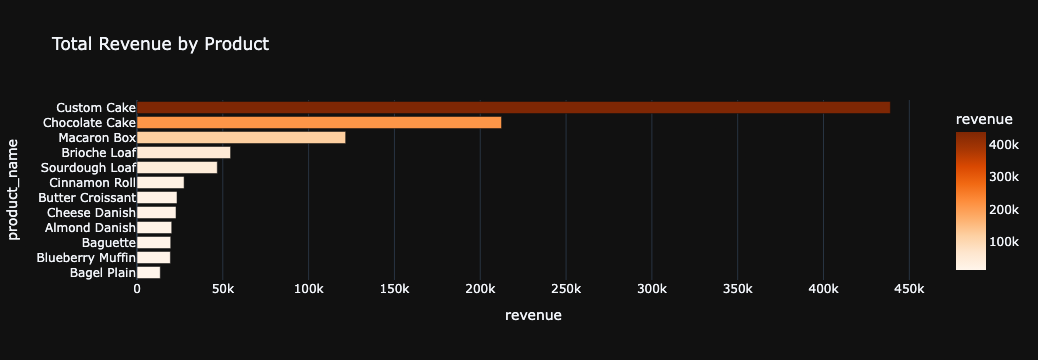

In [8]:
top_products = sales.groupby("product_name")["revenue"].sum().sort_values(ascending=True).reset_index()

fig = px.bar(
    top_products, x="revenue", y="product_name",
    orientation="h",
    title="Total Revenue by Product",
    template="plotly_dark",
    color="revenue",
    color_continuous_scale="Oranges"
)
fig.show()

#### Weekend vs Weekday revenue comparison:

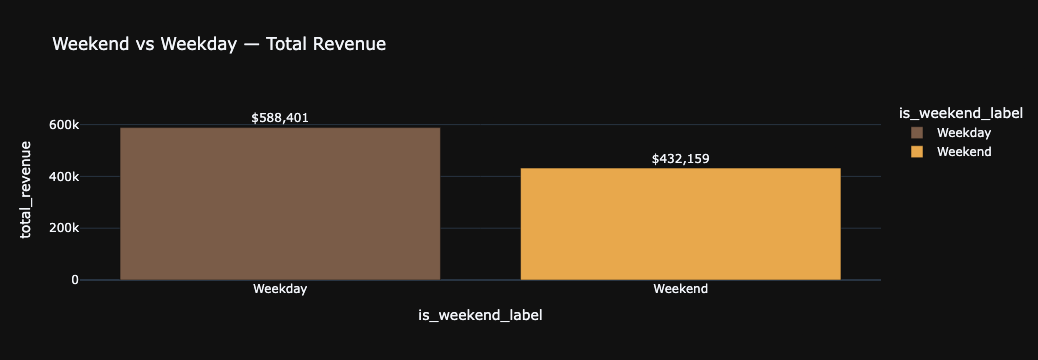

In [9]:
sales["is_weekend_label"] = sales["is_weekend"].map({True: "Weekend", False: "Weekday"})

weekend_comp = sales.groupby("is_weekend_label").agg(
    total_revenue=("revenue", "sum"),
    avg_daily_revenue=("revenue", "mean"),
    total_transactions=("transaction_id", "count")
).reset_index()

fig = px.bar(
    weekend_comp, x="is_weekend_label", y="total_revenue",
    title="Weekend vs Weekday — Total Revenue",
    template="plotly_dark",
    color="is_weekend_label",
    color_discrete_map={"Weekend": "#E8A84C", "Weekday": "#7A5C48"},
    text="total_revenue"
)
fig.update_traces(texttemplate="$%{text:,.0f}", textposition="outside")
fig.show()

#### Hourly demand pattern:

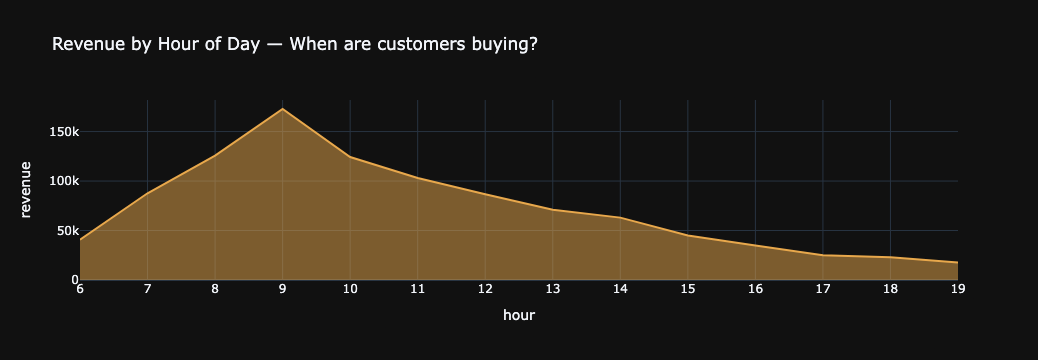

In [10]:
hourly = sales.groupby("hour")["revenue"].sum().reset_index()

fig = px.area(
    hourly, x="hour", y="revenue",
    title="Revenue by Hour of Day — When are customers buying?",
    template="plotly_dark",
    color_discrete_sequence=["#E8A84C"]
)
fig.update_layout(xaxis=dict(tickmode="linear", tick0=6, dtick=1))
fig.show()

#### Waste analysis by product:

In [11]:
waste = inventory.groupby("product_name").agg(
    total_wasted=("units_wasted", "sum"),
    total_baked=("units_baked", "sum"),
    total_waste_cost=("waste_cost_usd", "sum")
).reset_index()


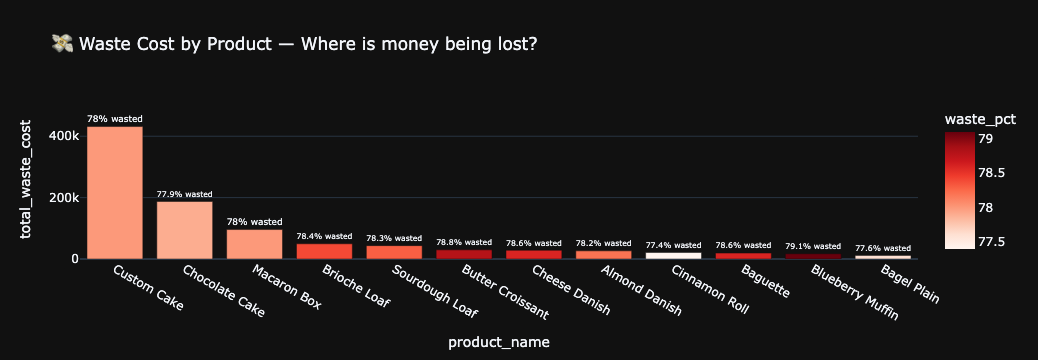

In [12]:
waste = inventory.groupby("product_name").agg(
    total_wasted=("units_wasted", "sum"),
    total_baked=("units_baked", "sum"),
    total_waste_cost=("waste_cost_usd", "sum")
).reset_index()

waste["waste_pct"] = round(waste["total_wasted"] / waste["total_baked"] * 100, 1)
waste = waste.sort_values("total_waste_cost", ascending=False)

fig = px.bar(
    waste, x="product_name", y="total_waste_cost",
    title="💸 Waste Cost by Product — Where is money being lost?",
    template="plotly_dark",
    color="waste_pct",
    color_continuous_scale="Reds",
    text="waste_pct"
)
fig.update_traces(texttemplate="%{text}% wasted", textposition="outside")
fig.show()

In [13]:
print(waste.columns.tolist())

['product_name', 'total_wasted', 'total_baked', 'total_waste_cost', 'waste_pct']


#### Staff overstaffing cost by day:

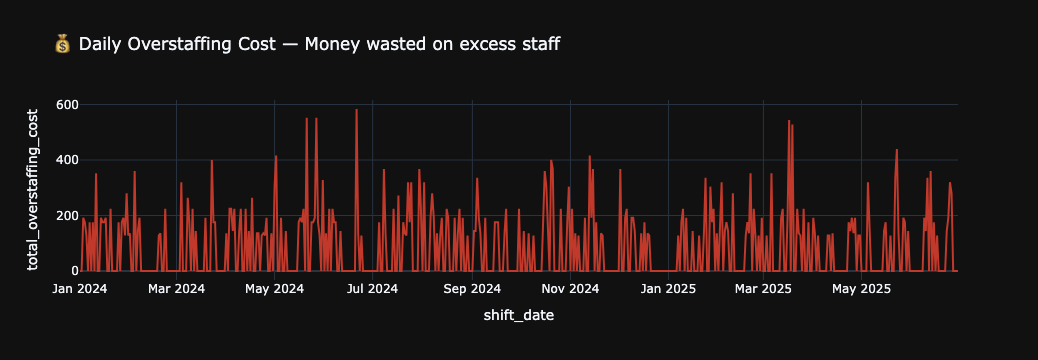

In [14]:
staff_cost = staff.groupby("shift_date").agg(
    total_overstaffing_cost=("overstaffing_cost", "sum"),
    total_scheduled=("scheduled_count", "sum"),
    total_recommended=("recommended_count", "sum")
).reset_index()

fig = px.line(
    staff_cost, x="shift_date", y="total_overstaffing_cost",
    title="💰 Daily Overstaffing Cost — Money wasted on excess staff",
    template="plotly_dark",
    color_discrete_sequence=["#C0392B"]
)
fig.show()

#### Holidays demand spike

In [17]:
sales["date"] = sales["transaction_ts"].dt.date
daily = sales.groupby("date")["revenue"].sum().reset_index()
daily["date"] = pd.to_datetime(daily["date"])

In [19]:
#yearly filter

daily_2024 = daily[(daily["date"] >= "2024-01-01") & (daily["date"] <= "2024-12-31")]
holidays_2024 = holidays[(holidays["holiday_date"] >= "2024-01-01") & (holidays["holiday_date"] <= "2024-12-31")]

fig = px.line(
    daily_2024, x="date", y="revenue",
    title="📅 Daily Revenue with Holiday Spikes — 2024",
    template="plotly_dark",
    color_discrete_sequence=["#E8A84C"]
)

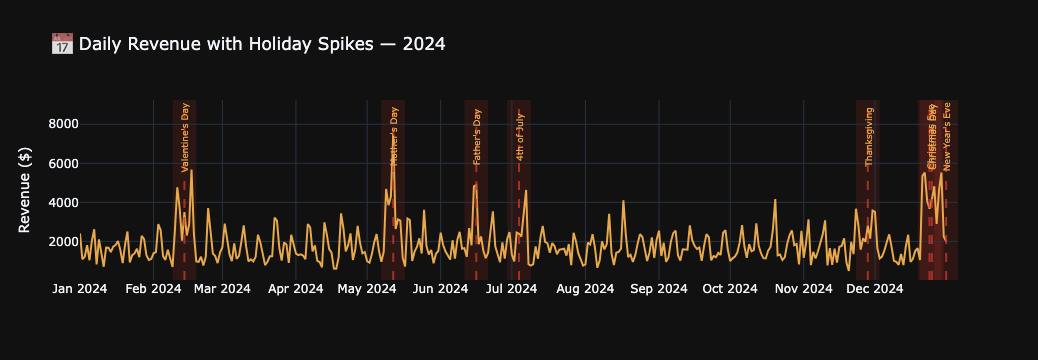

In [20]:
# Add shaded window ±5 days around each holiday
for _, h in holidays_2024.iterrows():
    window_start = h["holiday_date"] - pd.Timedelta(days=5)
    window_end   = h["holiday_date"] + pd.Timedelta(days=5)
    # Shaded region
    fig.add_vrect(
        x0=window_start, x1=window_end,
        fillcolor="rgba(192,57,43,0.15)",
        layer="below", line_width=0
    )
    # Vertical line on exact holiday
    fig.add_vline(
        x=h["holiday_date"],
        line_dash="dash",
        line_color="#C0392B",
        opacity=0.8
    )
    # Label
    fig.add_annotation(
        x=h["holiday_date"],
        y=daily_2024["revenue"].max() * 0.98,
        text=h["holiday_name"],
        showarrow=False,
        textangle=-90,
        font=dict(size=9, color="#E8A84C")
    )
fig.update_layout(
    xaxis=dict(
        tickformat="%b %Y",
        tickmode="array",
        tickvals=pd.date_range("2024-01-01", "2024-12-31", freq="MS")
    ),
    yaxis_title="Revenue ($)",
    xaxis_title=""
)
fig.show()

#### Category performance:

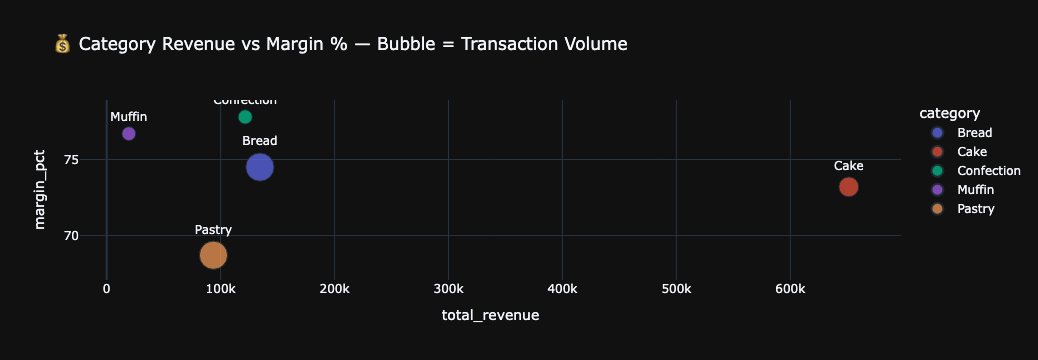

In [21]:
cat = sales.groupby("category").agg(
    total_revenue=("revenue", "sum"),
    total_margin=("gross_margin", "sum"),
    transactions=("transaction_id", "count")
).reset_index()

cat["margin_pct"] = round(cat["total_margin"] / cat["total_revenue"] * 100, 1)

fig = px.scatter(
    cat, x="total_revenue", y="margin_pct",
    size="transactions", color="category",
    title="💰 Category Revenue vs Margin % — Bubble = Transaction Volume",
    template="plotly_dark",
    text="category"
)
fig.update_traces(textposition="top center")
fig.show()

### Summary Insight

In [22]:
print("=" * 50)
print("📊 KEY BUSINESS INSIGHTS FROM EDA")
print("=" * 50)

# Best day
best_day = sales.groupby("day_of_week")["revenue"].sum().idxmax()
print(f"\n📅 Best sales day:       {best_day}")

# Best hour
best_hour = sales.groupby("hour")["revenue"].sum().idxmax()
print(f"⏰ Peak hour:            {best_hour}:00")

# Best product
best_product = sales.groupby("product_name")["revenue"].sum().idxmax()
print(f"🥐 Top product:          {best_product}")

# Most wasteful product
most_waste = inventory.groupby("product_name")["units_wasted"].sum().idxmax()
print(f"🗑️  Most wasted product:  {most_waste}")

# Total overstaffing cost
total_overstaff = staff["overstaffing_cost"].sum()
print(f"👨‍🍳 Total overstaffing cost: ${total_overstaff:,.2f}")

# Avg daily waste cost
avg_waste = inventory.groupby("baked_date")["waste_cost_usd"].sum().mean()
print(f"💸 Avg daily waste cost: ${avg_waste:,.2f}")
print("=" * 50)

📊 KEY BUSINESS INSIGHTS FROM EDA

📅 Best sales day:       Sunday
⏰ Peak hour:            9:00
🥐 Top product:          Custom Cake
🗑️  Most wasted product:  Butter Croissant
👨‍🍳 Total overstaffing cost: $45,048.00
💸 Avg daily waste cost: $1,759.13


In [26]:
df = pd.read_csv("../data/processed/daily_sales_features.csv", parse_dates=["transaction_date"])

print(f"Shape: {df.shape}")

Shape: (6436, 26)


In [27]:
print(f"\nColumns:\n{df.columns.tolist()}")


Columns:
['transaction_date', 'product_id', 'product_name', 'category', 'units_sold', 'revenue', 'cogs', 'gross_margin', 'transactions', 'margin_pct', 'lag_1d', 'lag_7d', 'lag_14d', 'rolling_7d_avg', 'rolling_30d_avg', 'day_of_week', 'day_of_week_num', 'is_weekend', 'month', 'week', 'year', 'quarter', 'is_holiday_window', 'holiday_name', 'demand_multiplier', 'days_to_holiday']


In [31]:
print(f"\nSample row:")
print(df[df["product_name"] == "Butter Croissant"].head(2).T)


Sample row:
                                     0                    1
transaction_date   2024-01-08 00:00:00  2024-01-09 00:00:00
product_id                        P001                 P001
product_name          Butter Croissant     Butter Croissant
category                        Pastry               Pastry
units_sold                          13                   18
revenue                           45.5                 63.0
cogs                              15.6                 21.6
gross_margin                      29.9                 41.4
transactions                         6                   11
margin_pct                       65.71                65.71
lag_1d                            15.0                 13.0
lag_7d                            11.0                  9.0
lag_14d                            NaN                  NaN
rolling_7d_avg                    11.0            11.285714
rolling_30d_avg                   11.0                11.25
day_of_week                